In [2]:
!pip -q install numpy scipy matplotlib scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("NumPy:", np.__version__)
def wrap_phase(phi):
    """
    Wrap phase to [-pi, pi).
    Useful only for visualization.
    """
    return (phi + np.pi) % (2 * np.pi) - np.pi


def gaussian_2d(x, y, delta=0.3):
    """
    Paper Eq. (17):
    g(x,y,Delta) = 1 / (2*pi*Delta^2) * exp(-(x^2 + y^2)/(2*Delta^2))
    """
    return (1.0 / (2.0 * np.pi * delta**2)) * np.exp(-(x**2 + y**2) / (2.0 * delta**2))


def epsilon_pattern(x, y, pattern_id=1):
    """
    Paper Eq. (22), three spatial phase patterns.

    pattern_id = 1: 2*x^2 + 4*y
    pattern_id = 2: 4*x + 4*y
    pattern_id = 3: 4*(0.2*x)^2 + 2*y
    """
    if pattern_id == 1:
        return 2.0 * x**2 + 4.0 * y
    elif pattern_id == 2:
        return 4.0 * x + 4.0 * y
    elif pattern_id == 3:
        return 4.0 * (0.2 * x)**2 + 2.0 * y
    else:
        raise ValueError("pattern_id must be 1, 2, or 3")

NumPy: 2.0.2


In [3]:
def generate_synthetic_interferometer_data(
    n_images=100,
    image_size=128,
    x_limit=1.8,
    y_limit=1.2,
    delta_x=1.0,
    cloud_width=0.3,
    contrast=1.0,
    pattern_id=1,
):
    """
    Generate synthetic two-port atom-interferometer images.

    Output:
        images: shape (n_images, image_size, image_size)
        gamma: true spatial phase map, shape (image_size, image_size)
        theta: true phase scan values, shape (n_images,)
        X, Y: coordinate grids
        mean_image: average image over phase scan
    """

    # Coordinate grid
    x = np.linspace(-x_limit, x_limit, image_size)
    y = np.linspace(-y_limit, y_limit, image_size)
    X, Y = np.meshgrid(x, y)

    # Right port: X >= 0, centered near +delta_x
    # Left port: X < 0, centered near -delta_x
    X_shifted = np.where(X >= 0, X - delta_x, X + delta_x)

    # Gaussian envelope for each port
    envelope = 0.5 * gaussian_2d(X_shifted, Y, delta=cloud_width)

    # Spatial phase profile gamma(x,y)
    # Left port has additional pi phase shift
    eps = epsilon_pattern(X_shifted, Y, pattern_id=pattern_id)
    gamma = np.where(X >= 0, eps, eps + np.pi)

    # Phase scan theta(i) = 2*pi*i/n_images
    theta = 2.0 * np.pi * np.arange(n_images) / n_images

    # Build image stack:
    # I(i,x,y) = envelope(x,y) * [1 + C*cos(theta(i) + gamma(x,y))]
    images = envelope[None, :, :] * (
        1.0 + contrast * np.cos(theta[:, None, None] + gamma[None, :, :])
    )

    mean_image = images.mean(axis=0)

    return images, gamma, theta, X, Y, mean_image


images shape: (100, 128, 128)
gamma_true shape: (128, 128)
theta_true shape: (100,)
min/max image intensity: 8.922200176697044e-16 1.766846601571373


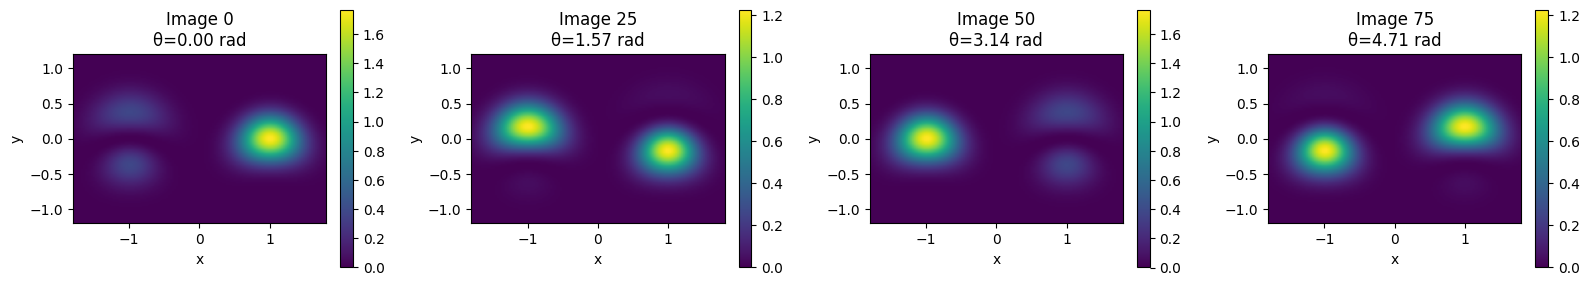

In [4]:
# Choose pattern 1, 2, or 3
pattern_id = 1

images, gamma_true, theta_true, X, Y, mean_image = generate_synthetic_interferometer_data(
    n_images=100,
    image_size=128,
    pattern_id=pattern_id,
    contrast=1.0
)

print("images shape:", images.shape)
print("gamma_true shape:", gamma_true.shape)
print("theta_true shape:", theta_true.shape)
print("min/max image intensity:", images.min(), images.max())
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

image_indices = [0, 25, 50, 75]

for ax, idx in zip(axes, image_indices):
    im = ax.imshow(
        images[idx],
        origin="lower",
        extent=[X.min(), X.max(), Y.min(), Y.max()]
    )
    ax.set_title(f"Image {idx}\nθ={theta_true[idx]:.2f} rad")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

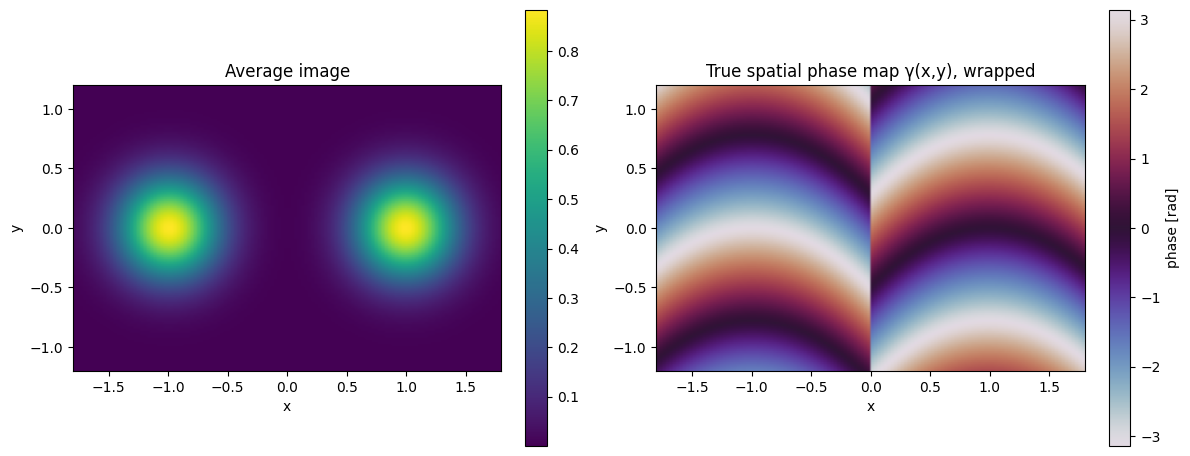

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(
    mean_image,
    origin="lower",
    extent=[X.min(), X.max(), Y.min(), Y.max()]
)
axes[0].set_title("Average image")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    wrap_phase(gamma_true),
    origin="lower",
    extent=[X.min(), X.max(), Y.min(), Y.max()],
    cmap="twilight"
)
axes[1].set_title("True spatial phase map γ(x,y), wrapped")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1], fraction=0.046, label="phase [rad]")

plt.tight_layout()
plt.show()

In [6]:
datasets = {}

for pid in [1, 2, 3]:
    images_pid, gamma_pid, theta_pid, X_pid, Y_pid, mean_pid = generate_synthetic_interferometer_data(
        n_images=100,
        image_size=128,
        pattern_id=pid,
        contrast=1.0
    )

    datasets[pid] = {
        "images": images_pid,
        "gamma_true": gamma_pid,
        "theta_true": theta_pid,
        "X": X_pid,
        "Y": Y_pid,
        "mean_image": mean_pid,
    }

print("Generated datasets:", datasets.keys())
for pid in datasets:
    print(f"Pattern {pid}: images shape =", datasets[pid]["images"].shape)

Generated datasets: dict_keys([1, 2, 3])
Pattern 1: images shape = (100, 128, 128)
Pattern 2: images shape = (100, 128, 128)
Pattern 3: images shape = (100, 128, 128)


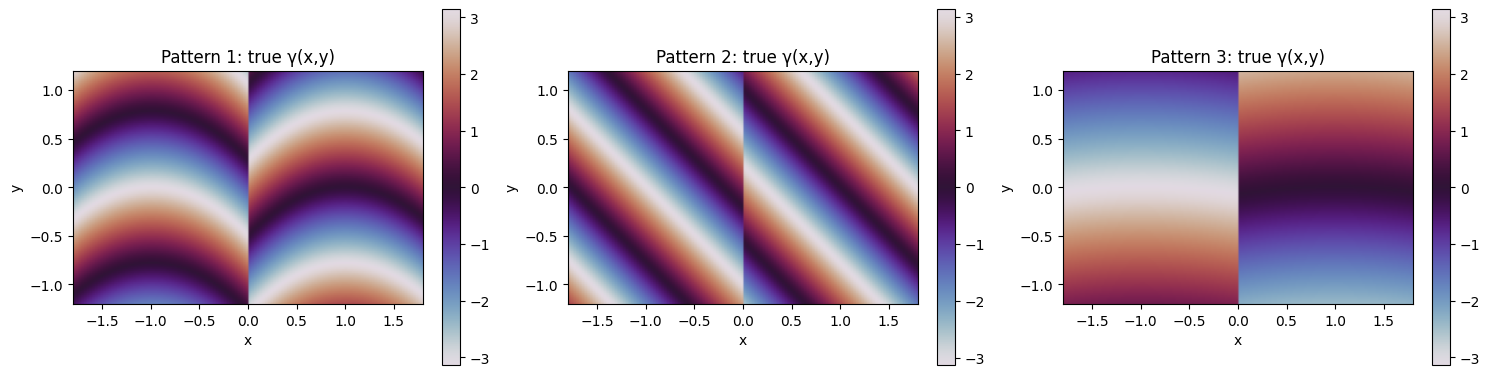

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pid in zip(axes, [1, 2, 3]):
    data = datasets[pid]
    im = ax.imshow(
        wrap_phase(data["gamma_true"]),
        origin="lower",
        extent=[data["X"].min(), data["X"].max(), data["Y"].min(), data["Y"].max()],
        cmap="twilight"
    )
    ax.set_title(f"Pattern {pid}: true γ(x,y)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

In [8]:
output_dir = Path("synthetic_pspr_data")
output_dir.mkdir(exist_ok=True)

for pid, data in datasets.items():
    np.savez_compressed(
        output_dir / f"synthetic_pattern_{pid}.npz",
        images=data["images"],
        gamma_true=data["gamma_true"],
        theta_true=data["theta_true"],
        X=data["X"],
        Y=data["Y"],
        mean_image=data["mean_image"],
    )

print("Saved files:")
for file in output_dir.glob("*.npz"):
    print(file)
loaded = np.load("synthetic_pspr_data/synthetic_pattern_1.npz")

images_loaded = loaded["images"]
gamma_loaded = loaded["gamma_true"]
theta_loaded = loaded["theta_true"]

print("Loaded images:", images_loaded.shape)
print("Loaded gamma:", gamma_loaded.shape)
print("Loaded theta:", theta_loaded.shape)

Saved files:
synthetic_pspr_data/synthetic_pattern_2.npz
synthetic_pspr_data/synthetic_pattern_1.npz
synthetic_pspr_data/synthetic_pattern_3.npz
Loaded images: (100, 128, 128)
Loaded gamma: (128, 128)
Loaded theta: (100,)


In [9]:
#step 2

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import BoundaryNorm

def wrap_phase(phi):
    return (phi + np.pi) % (2 * np.pi) - np.pi


def phase_mod_2pi_over_pi(phi):
    """
    Paper-like left plot:
    gamma(x,y) / pi in range [0, 2]
    """
    return np.mod(phi, 2 * np.pi) / np.pi


def gaussian_2d(x, y, delta=0.3):
    return (1.0 / (2.0 * np.pi * delta**2)) * np.exp(
        -(x**2 + y**2) / (2.0 * delta**2)
    )


def epsilon_pattern(x, y, pattern_id=1):
    if pattern_id == 1:
        return 2.0 * x**2 + 4.0 * y
    elif pattern_id == 2:
        return 4.0 * x + 4.0 * y
    elif pattern_id == 3:
        return 4.0 * (0.2 * x)**2 + 2.0 * y
    else:
        raise ValueError("pattern_id must be 1, 2, or 3")


def generate_synthetic_interferometer_data_rectangular(
    n_images=100,
    width=220,
    height=170,
    x_limit=2.0,
    y_limit=1.0,
    delta_x=1.0,
    cloud_width=0.3,
    contrast=1.0,
    pattern_id=1,
):
    """
    More paper-like synthetic grid:
    x from -2 to 2
    y from -1 to 1
    rectangular image, e.g. 50 x 100
    """

    x = np.linspace(-x_limit, x_limit, width)
    y = np.linspace(-y_limit, y_limit, height)
    X, Y = np.meshgrid(x, y)

    X_shifted = np.where(X >= 0, X - delta_x, X + delta_x)

    envelope = 0.5 * gaussian_2d(X_shifted, Y, delta=cloud_width)

    eps = epsilon_pattern(X_shifted, Y, pattern_id=pattern_id)
    gamma = np.where(X >= 0, eps, eps + np.pi)

    theta = 2.0 * np.pi * np.arange(n_images) / n_images

    images = envelope[None, :, :] * (
        1.0 + contrast * np.cos(theta[:, None, None] + gamma[None, :, :])
    )

    mean_image = images.mean(axis=0)

    return images, gamma, theta, X, Y, mean_image

In [11]:
def phase_difference(phi1, phi2):
    return wrap_phase(phi1 - phi2)


def circular_mean_angle(angles):
    return np.arctan2(np.mean(np.sin(angles)), np.mean(np.cos(angles)))


def fast_pca_gram(images, n_components=2):
    n_images, height, width = images.shape

    X = images.reshape(n_images, height * width)
    mean_flat = X.mean(axis=0)
    X_centered = X - mean_flat

    gram = X_centered @ X_centered.T

    eigvals, eigvecs = np.linalg.eigh(gram)

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    selected_eigvals = eigvals[:n_components]
    selected_eigvecs = eigvecs[:, :n_components]

    singular_values = np.sqrt(np.maximum(selected_eigvals, 0.0))

    scores = selected_eigvecs * singular_values[None, :]

    components_flat = []

    for j in range(n_components):
        component_j = selected_eigvecs[:, j].T @ X_centered / singular_values[j]

        max_index = np.argmax(np.abs(component_j))
        if component_j[max_index] < 0:
            component_j *= -1
            scores[:, j] *= -1

        components_flat.append(component_j)

    components_flat = np.array(components_flat)

    mean_image = mean_flat.reshape(height, width)
    components = components_flat.reshape(n_components, height, width)

    return mean_image, components, scores, selected_eigvals


def pspr_reconstruct_noise_free(images):
    n_images, height, width = images.shape

    mean_image, components, scores, eigenvalues = fast_pca_gram(
        images,
        n_components=2
    )

    W = scores.copy()
    P = components.reshape(2, height * width).copy()

    center = W.mean(axis=0)
    W_centered = W - center

    cov = (W_centered.T @ W_centered) / n_images

    eigvals, R = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    R = R[:, order]

    if np.linalg.det(R) < 0:
        R[:, 1] *= -1

    T = R @ np.diag(1.0 / np.sqrt(eigvals))
    W_corrected = W_centered @ T

    P_corrected = np.diag(np.sqrt(eigvals)) @ R.T @ P
    P_corrected = P_corrected.reshape(2, height, width)

    theta_rec = np.arctan2(W_corrected[:, 1], W_corrected[:, 0])
    gamma_rec = np.arctan2(-P_corrected[1], P_corrected[0])

    return {
        "mean_image": mean_image,
        "components": components,
        "scores": scores,
        "eigenvalues": eigenvalues,
        "W_corrected": W_corrected,
        "P_corrected": P_corrected,
        "theta_rec": theta_rec,
        "gamma_rec": gamma_rec,
    }


def align_reconstructed_phases(theta_true, theta_rec, gamma_true, gamma_rec):
    best = None

    for sign in [+1, -1]:
        offset = circular_mean_angle(sign * theta_true - theta_rec)

        theta_aligned = sign * theta_true - offset
        theta_diff = phase_difference(theta_aligned, theta_rec)

        error = np.mean(theta_diff**2)

        if best is None or error < best["error"]:
            best = {
                "error": error,
                "sign": sign,
                "offset": offset,
                "theta_diff": theta_diff,
            }

    sign = best["sign"]
    offset = best["offset"]

    gamma_aligned = sign * gamma_true + offset
    gamma_diff = phase_difference(gamma_aligned, gamma_rec)

    return {
        "sign": sign,
        "offset": offset,
        "theta_diff": best["theta_diff"],
        "gamma_diff": gamma_diff,
    }

In [12]:
datasets = {}
results = {}

for pattern_id in [1, 2, 3]:
    images, gamma_true, theta_true, X, Y, mean_image = generate_synthetic_interferometer_data_rectangular(
        n_images=100,
        width=120,       # closer to paper pixel grid
        height=60,       # closer to paper pixel grid
        x_limit=2.0,
        y_limit=1.0,
        pattern_id=pattern_id,
        contrast=1.0
    )

    reconstruction = pspr_reconstruct_noise_free(images)

    alignment = align_reconstructed_phases(
        theta_true=theta_true,
        theta_rec=reconstruction["theta_rec"],
        gamma_true=gamma_true,
        gamma_rec=reconstruction["gamma_rec"],
    )

    results[pattern_id] = {
        "images": images,
        "gamma_true": gamma_true,
        "theta_true": theta_true,
        "X": X,
        "Y": Y,
        "mean_image": mean_image,
        **reconstruction,
        **alignment,
    }

    atom_mask = mean_image > mean_image.max() * 1e-5

    print(f"Pattern {pattern_id}")
    print("  image shape:", images.shape)
    print("  max |theta_diff|:", np.max(np.abs(alignment["theta_diff"])))
    print("  RMS gamma_diff:", np.sqrt(np.mean(alignment["gamma_diff"][atom_mask]**2)))
    print("  max |gamma_diff|:", np.max(np.abs(alignment["gamma_diff"][atom_mask])))

Pattern 1
  image shape: (100, 60, 120)
  max |theta_diff|: 2.220446049250313e-15
  RMS gamma_diff: 1.5569533786646923e-16
  max |gamma_diff|: 8.881784197001252e-16
Pattern 2
  image shape: (100, 60, 120)
  max |theta_diff|: 4.440892098500626e-16
  RMS gamma_diff: 5.804389243823509e-17
  max |gamma_diff|: 4.440892098500626e-16
Pattern 3
  image shape: (100, 60, 120)
  max |theta_diff|: 3.9968028886505635e-15
  RMS gamma_diff: 1.0188812680915911e-16
  max |gamma_diff|: 4.440892098500626e-16


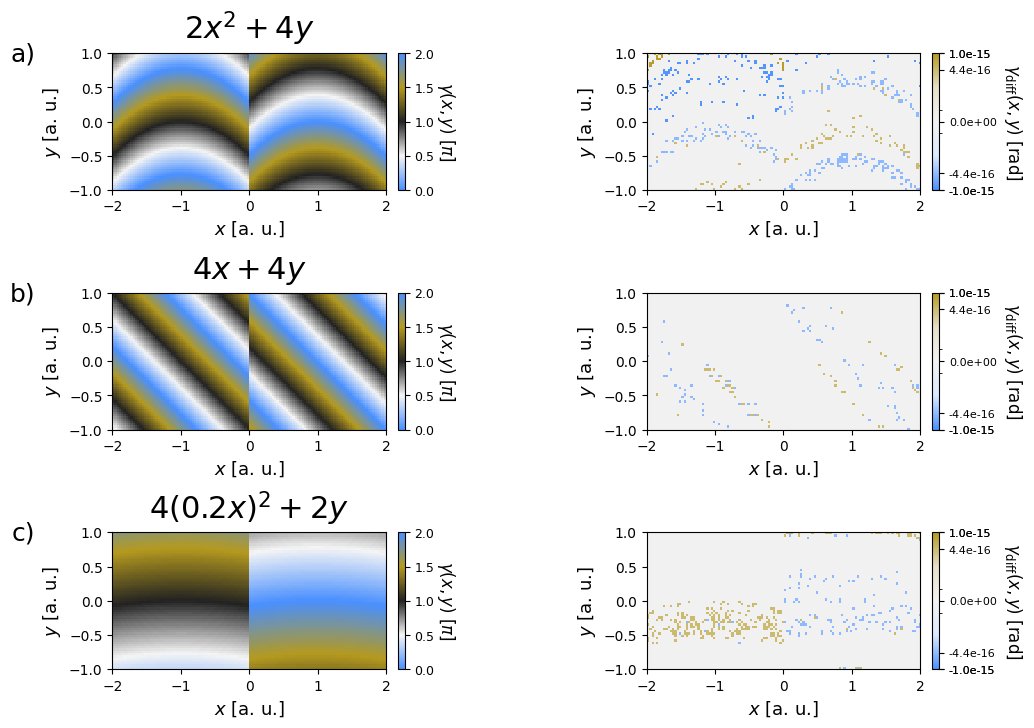

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm

# -----------------------------
# Paper-like phase colormap
# blue -> white -> black -> gold -> blue
# -----------------------------
paper_phase_cmap = LinearSegmentedColormap.from_list(
    "paper_phase_cmap",
    [
        (0.00, "#4a90ff"),  # blue
        (0.25, "#f5f5f5"),  # white
        (0.50, "#222222"),  # black
        (0.75, "#b59a1f"),  # gold
        (1.00, "#4a90ff"),  # blue again
    ],
    N=256
)

# -----------------------------
# Paper-like difference colormap
# blue = negative, gray = zero, gold = positive
# -----------------------------
paper_diff_cmap = LinearSegmentedColormap.from_list(
    "paper_diff_cmap",
    [
        (0.00, "#4a90ff"),
        (0.25, "#dce9ff"),
        (0.50, "#f2f2f2"),
        (0.75, "#e6dfc8"),
        (1.00, "#b59a1f"),
    ],
    N=256
)

def gamma_over_pi_0_to_2(gamma):
    return np.mod(gamma, 2 * np.pi) / np.pi

pattern_titles = {
    1: r"$2x^2 + 4y$",
    2: r"$4x + 4y$",
    3: r"$4(0.2x)^2 + 2y$",
}

row_labels = {
    1: "a)",
    2: "b)",
    3: "c)",
}

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 8),
    gridspec_kw={
        "width_ratios": [1.0, 1.0],
        "hspace": 0.75,
        "wspace": 0.35,
    }
)

for row, pattern_id in enumerate([1, 2, 3]):

    res = results[pattern_id]

    extent = [
        res["X"].min(),
        res["X"].max(),
        res["Y"].min(),
        res["Y"].max(),
    ]

    # ============================================================
    # LEFT: true spatial phase gamma(x,y)/pi
    # ============================================================
    ax_left = axes[row, 0]

    gamma_plot = gamma_over_pi_0_to_2(res["gamma_true"])

    im_left = ax_left.imshow(
        gamma_plot,
        origin="lower",
        extent=extent,
        cmap=paper_phase_cmap,
        vmin=0,
        vmax=2,
        interpolation="nearest",
        aspect="equal",
    )

    ax_left.set_title(pattern_titles[pattern_id], fontsize=22, pad=10)
    ax_left.set_xlabel(r"$x$ [a. u.]", fontsize=13)
    ax_left.set_ylabel(r"$y$ [a. u.]", fontsize=13)
    ax_left.tick_params(labelsize=10)

    ax_left.text(
        -0.28, 1.08,
        row_labels[pattern_id],
        transform=ax_left.transAxes,
        fontsize=18,
        ha="right",
        va="top"
    )

    cbar_left = plt.colorbar(im_left, ax=ax_left, fraction=0.045, pad=0.03)
    cbar_left.set_ticks([0, 0.5, 1, 1.5, 2])
    cbar_left.ax.tick_params(labelsize=9)
    cbar_left.set_label(
        r"$\gamma(x,y)$ [$\pi$]",
        rotation=270,
        labelpad=16,
        fontsize=12
    )

    # ============================================================
    # RIGHT: reconstruction difference gamma_diff(x,y)
    # ============================================================
    ax_right = axes[row, 1]

    gamma_diff = res["gamma_diff"]

    # Use actual numerical range but protect against all-zero case
    vmax = np.max(np.abs(gamma_diff))
    vmax = max(vmax, 1e-15)

    norm = SymLogNorm(
        linthresh=4.4e-16,
        linscale=1.0,
        vmin=-vmax,
        vmax=vmax,
        base=10
    )

    im_right = ax_right.imshow(
        gamma_diff,
        origin="lower",
        extent=extent,
        cmap=paper_diff_cmap,
        norm=norm,
        interpolation="nearest",
        aspect="equal",
    )

    ax_right.set_xlabel(r"$x$ [a. u.]", fontsize=13)
    ax_right.set_ylabel(r"$y$ [a. u.]", fontsize=13)
    ax_right.tick_params(labelsize=10)

    cbar_right = plt.colorbar(im_right, ax=ax_right, fraction=0.045, pad=0.03)

    # Paper-like ticks: include 10^-16 scale and outlier scale
    ticks = [
        -vmax,
        -1e-15,
        -4.4e-16,
        0,
        4.4e-16,
        1e-15,
        vmax,
    ]

    cbar_right.set_ticks(ticks)
    cbar_right.set_ticklabels([
        f"{-vmax:.1e}",
        "-1.0e-15",
        "-4.4e-16",
        "0.0e+00",
        "4.4e-16",
        "1.0e-15",
        f"{vmax:.1e}",
    ])
    cbar_right.ax.tick_params(labelsize=8)
    cbar_right.set_label(
        r"$\gamma_{\mathrm{diff}}(x,y)$ [rad]",
        rotation=270,
        labelpad=20,
        fontsize=12
    )

plt.show()

In [ ]:
#step 3

In [15]:
!pip -q install numpy scipy matplotlib scikit-image

import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import EllipseModel
from pathlib import Path
import time

print("NumPy:", np.__version__)

NumPy: 2.0.2


In [20]:
def wrap_phase(phi):
    return (phi + np.pi) % (2 * np.pi) - np.pi


def phase_difference(phi1, phi2):
    return wrap_phase(phi1 - phi2)


def circular_mean_angle(angles):
    return np.arctan2(np.mean(np.sin(angles)), np.mean(np.cos(angles)))


def gaussian_2d(x, y, delta=0.3):
    return (1.0 / (2.0 * np.pi * delta**2)) * np.exp(
        -(x**2 + y**2) / (2.0 * delta**2)
    )


def epsilon_pattern(x, y, pattern_id):
    if pattern_id == 1:
        return 2.0 * x**2 + 4.0 * y
    elif pattern_id == 2:
        return 4.0 * x + 4.0 * y
    elif pattern_id == 3:
        return 4.0 * (0.2 * x)**2 + 2.0 * y
    else:
        raise ValueError("pattern_id must be 1, 2, or 3")


def generate_noiseless_synthetic_images(
    n_images=1000,
    width=80,
    height=40,
    x_limit=2.0,
    y_limit=1.0,
    delta_x=1.0,
    cloud_width=0.3,
    contrast=1.0,
    pattern_id=1,
):
    """
    Paper synthetic model:
    two Gaussian ports, left port has extra pi phase.
    """

    x = np.linspace(-x_limit, x_limit, width)
    y = np.linspace(-y_limit, y_limit, height)
    X, Y = np.meshgrid(x, y)

    X_shifted = np.where(X >= 0, X - delta_x, X + delta_x)

    envelope = 0.5 * gaussian_2d(X_shifted, Y, delta=cloud_width)

    eps = epsilon_pattern(X_shifted, Y, pattern_id)
    gamma_true = np.where(X >= 0, eps, eps + np.pi)

    theta_true = 2.0 * np.pi * np.arange(n_images) / n_images

    images = envelope[None, :, :] * (
        1.0 + contrast * np.cos(theta_true[:, None, None] + gamma_true[None, :, :])
    )

    return images, gamma_true, theta_true, X, Y


def add_atom_shot_noise(noiseless_images, n_atoms=100_000, rng=None):
    """
    Shot noise:
    each image intensity becomes a probability distribution,
    then n_atoms are sampled into pixels.
    """

    if rng is None:
        rng = np.random.default_rng()

    n_images, height, width = noiseless_images.shape
    noisy_images = np.empty_like(noiseless_images, dtype=np.float64)

    flat = noiseless_images.reshape(n_images, height * width)

    for i in range(n_images):
        p = flat[i].astype(np.float64)
        p_sum = p.sum()

        if p_sum <= 0:
            raise ValueError("Zero total intensity.")

        p = p / p_sum
        counts = rng.multinomial(n_atoms, p)
        noisy_images[i] = counts.reshape(height, width)

    return noisy_images


def expected_mean_atom_counts(noiseless_images, n_atoms):
    """
    Expected mean atom count per pixel per image:
    Ibar(x,y) in atoms/image.
    """

    n_images, height, width = noiseless_images.shape
    flat = noiseless_images.reshape(n_images, height * width)

    probs = flat / flat.sum(axis=1, keepdims=True)
    mean_counts = n_atoms * probs.mean(axis=0)

    return mean_counts.reshape(height, width)
def fast_pca_gram(images, n_components=2):
    n_images, height, width = images.shape

    X = images.reshape(n_images, height * width)
    mean_flat = X.mean(axis=0)
    Xc = X - mean_flat

    gram = Xc @ Xc.T

    eigvals, eigvecs = np.linalg.eigh(gram)

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    eigvals = eigvals[:n_components]
    eigvecs = eigvecs[:, :n_components]

    singular_values = np.sqrt(np.maximum(eigvals, 0.0))

    scores = eigvecs * singular_values[None, :]

    components_flat = []

    for j in range(n_components):
        component_j = eigvecs[:, j].T @ Xc / singular_values[j]

        max_index = np.argmax(np.abs(component_j))
        if component_j[max_index] < 0:
            component_j *= -1
            scores[:, j] *= -1

        components_flat.append(component_j)

    components_flat = np.array(components_flat)

    mean_image = mean_flat.reshape(height, width)
    components = components_flat.reshape(n_components, height, width)

    return mean_image, components, scores, eigvals


def fit_ellipse_to_coefficients(scores):
    """
    Paper convention:
    fit ellipse to points (w1, -w2).
    """

    points = np.column_stack([scores[:, 0], -scores[:, 1]])

    ellipse = EllipseModel()
    success = ellipse.estimate(points)

    if not success:
        raise RuntimeError("Ellipse fit failed.")

    xc, yc, a, b, angle = ellipse.params

    return xc, yc, a, b, angle, points


def pspr_reconstruct_exact(images):
    """
    PSPR:
    PCA -> ellipse fit -> ellipse correction -> arctan2.
    """

    n_images, height, width = images.shape

    mean_image, components, scores, eigvals = fast_pca_gram(images, n_components=2)

    xc, yc, a, b, angle, points = fit_ellipse_to_coefficients(scores)

    center = np.array([xc, yc])

    R_minus = np.array([
        [np.cos(-angle), -np.sin(-angle)],
        [np.sin(-angle),  np.cos(-angle)],
    ])

    R_plus = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)],
    ])

    # Correct coefficients, paper Eq. 7 style
    W_corrected = (points - center) @ R_minus.T @ np.diag([1.0 / a, 1.0 / b])

    # Correct components, paper Eq. 8 style
    P = components.reshape(2, height * width)
    P_corrected = np.diag([a, b]) @ R_plus @ P
    P_corrected = P_corrected.reshape(2, height, width)

    theta_rec = np.arctan2(W_corrected[:, 1], W_corrected[:, 0])
    gamma_rec = np.arctan2(P_corrected[1], P_corrected[0])

    return theta_rec, gamma_rec


def align_reconstructed_phases(theta_true, theta_rec, gamma_true, gamma_rec):
    """
    Remove PCA arbitrary sign and offset.
    """

    best = None

    for sign in [+1, -1]:
        offset = circular_mean_angle(sign * theta_true - theta_rec)

        theta_aligned = sign * theta_true - offset
        theta_diff = phase_difference(theta_aligned, theta_rec)

        mse = np.mean(theta_diff**2)

        if best is None or mse < best["mse"]:
            best = {
                "mse": mse,
                "sign": sign,
                "offset": offset,
                "theta_diff": theta_diff,
            }

    sign = best["sign"]
    offset = best["offset"]

    gamma_aligned = sign * gamma_true + offset
    gamma_diff = phase_difference(gamma_aligned, gamma_rec)

    return best["theta_diff"], gamma_diff
def estimate_theta_error_for_setting(
    pattern_id,
    n_atoms,
    n_images,
    n_runs,
    width=80,
    height=40,
    contrast=1.0,
    seed=0,
):
    """
    Returns:
        max_sigma_i = max over i of std(theta_diff(i))
    """

    rng = np.random.default_rng(seed)

    noiseless, gamma_true, theta_true, X, Y = generate_noiseless_synthetic_images(
        n_images=n_images,
        width=width,
        height=height,
        contrast=contrast,
        pattern_id=pattern_id,
    )

    theta_diffs = np.empty((n_runs, n_images), dtype=np.float64)

    failed = 0

    for r in range(n_runs):
        noisy = add_atom_shot_noise(noiseless, n_atoms=n_atoms, rng=rng)

        try:
            theta_rec, gamma_rec = pspr_reconstruct_exact(noisy)
            theta_diff, gamma_diff = align_reconstructed_phases(
                theta_true, theta_rec, gamma_true, gamma_rec
            )
            theta_diffs[r] = theta_diff

        except Exception as exc:
            failed += 1
            theta_diffs[r] = np.nan

    sigma_i = np.nanstd(theta_diffs, axis=0, ddof=1)
    max_sigma_i = np.nanmax(sigma_i)

    return max_sigma_i, sigma_i, failed


def estimate_gamma_xy_for_setting(
    pattern_id,
    n_atoms,
    n_images,
    n_runs,
    width=80,
    height=40,
    contrast=1.0,
    seed=0,
):
    """
    Returns pixel-wise sigma_xy and expected mean atom counts Ibar.
    """

    rng = np.random.default_rng(seed)

    noiseless, gamma_true, theta_true, X, Y = generate_noiseless_synthetic_images(
        n_images=n_images,
        width=width,
        height=height,
        contrast=contrast,
        pattern_id=pattern_id,
    )

    Ibar = expected_mean_atom_counts(noiseless, n_atoms=n_atoms)

    gamma_diffs = np.empty((n_runs, height, width), dtype=np.float64)

    failed = 0

    for r in range(n_runs):
        noisy = add_atom_shot_noise(noiseless, n_atoms=n_atoms, rng=rng)

        try:
            theta_rec, gamma_rec = pspr_reconstruct_exact(noisy)
            theta_diff, gamma_diff = align_reconstructed_phases(
                theta_true, theta_rec, gamma_true, gamma_rec
            )
            gamma_diffs[r] = gamma_diff

        except Exception as exc:
            failed += 1
            gamma_diffs[r] = np.nan

    sigma_xy = np.nanstd(gamma_diffs, axis=0, ddof=1)

    return sigma_xy, Ibar, failed


Pattern 1
N_atoms=      5, max_sigma_i=2.4111e+00, failed=0
N_atoms=     10, max_sigma_i=1.7105e+00, failed=0
N_atoms=     20, max_sigma_i=8.3293e-01, failed=0
N_atoms=     50, max_sigma_i=3.5974e-01, failed=0
N_atoms=    100, max_sigma_i=2.4567e-01, failed=0
N_atoms=    200, max_sigma_i=1.5763e-01, failed=0
N_atoms=    500, max_sigma_i=1.1183e-01, failed=0
N_atoms=   1000, max_sigma_i=8.0300e-02, failed=0
N_atoms=   2000, max_sigma_i=4.8380e-02, failed=0
N_atoms=   5000, max_sigma_i=3.2051e-02, failed=0
N_atoms=  10000, max_sigma_i=2.2042e-02, failed=0
N_atoms=  20000, max_sigma_i=1.5982e-02, failed=0
N_atoms=  50000, max_sigma_i=1.0781e-02, failed=0
N_atoms= 100000, max_sigma_i=7.3586e-03, failed=0

Pattern 2
N_atoms=      5, max_sigma_i=2.1273e+00, failed=0
N_atoms=     10, max_sigma_i=1.2762e+00, failed=0
N_atoms=     20, max_sigma_i=7.3034e-01, failed=0
N_atoms=     50, max_sigma_i=3.4930e-01, failed=0
N_atoms=    100, max_sigma_i=2.5540e-01, failed=0
N_atoms=    200, max_sigma_i

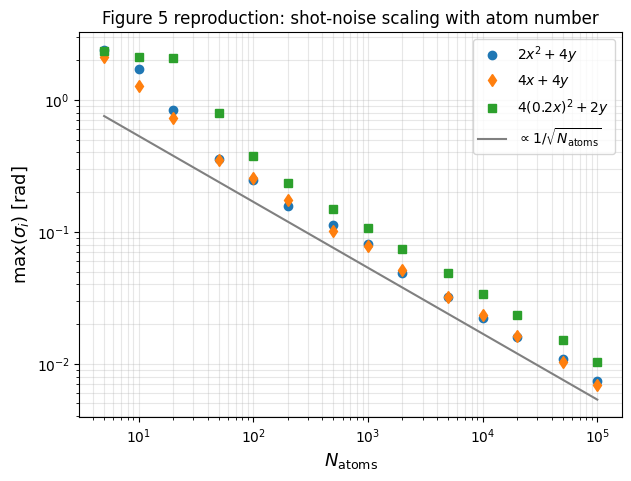

In [21]:
# ----------------------------
# Colab settings
# ----------------------------
N_RUNS = 30          # paper used ~120000; start small
N_IMAGES_FIG5 = 1000
WIDTH = 80
HEIGHT = 40
CONTRAST = 1.0

N_ATOMS_LIST = np.array([
    5,
    10,
    20,
    50,
    100,
    200,
    500,
    1_000,
    2_000,
    5_000,
    10_000,
    20_000,
    50_000,
    100_000,
])

fig5_results = {
    1: [],
    2: [],
    3: [],
}

start = time.time()

for pattern_id in [1, 2, 3]:
    print(f"\nPattern {pattern_id}")

    for n_atoms in N_ATOMS_LIST:
        max_sigma_i, sigma_i, failed = estimate_theta_error_for_setting(
            pattern_id=pattern_id,
            n_atoms=int(n_atoms),
            n_images=N_IMAGES_FIG5,
            n_runs=N_RUNS,
            width=WIDTH,
            height=HEIGHT,
            contrast=CONTRAST,
            seed=1000 + pattern_id * 100 + int(n_atoms),
        )

        fig5_results[pattern_id].append(max_sigma_i)

        print(
            f"N_atoms={n_atoms:>7}, "
            f"max_sigma_i={max_sigma_i:.4e}, "
            f"failed={failed}"
        )

print("\nElapsed time:", time.time() - start, "seconds")

for pattern_id in [1, 2, 3]:
    fig5_results[pattern_id] = np.array(fig5_results[pattern_id])
pattern_labels = {
    1: r"$2x^2 + 4y$",
    2: r"$4x + 4y$",
    3: r"$4(0.2x)^2 + 2y$",
}

paper_a = {
    1: 1.69,
    2: 1.67,
    3: 2.51,
}

markers = {
    1: "o",
    2: "d",
    3: "s",
}

plt.figure(figsize=(7, 5))

for pattern_id in [1, 2, 3]:
    plt.loglog(
        N_ATOMS_LIST,
        fig5_results[pattern_id],
        marker=markers[pattern_id],
        linestyle="none",
        label=pattern_labels[pattern_id],
    )

# Reference paper-like scaling
xline = np.logspace(np.log10(N_ATOMS_LIST.min()), np.log10(N_ATOMS_LIST.max()), 300)
plt.loglog(
    xline,
    1.69 / np.sqrt(xline),
    color="gray",
    linestyle="-",
    label=r"$\propto 1/\sqrt{N_{\mathrm{atoms}}}$"
)

plt.xlabel(r"$N_{\mathrm{atoms}}$", fontsize=13)
plt.ylabel(r"$\max(\sigma_i)$ [rad]", fontsize=13)
plt.title("Figure 5 reproduction: shot-noise scaling with atom number")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


Pattern 1
pattern=1, n_images=   10, max_sigma=5.853 mrad, p99_sigma=5.851 mrad, failed=0, time=1.7s
pattern=1, n_images=   15, max_sigma=5.736 mrad, p99_sigma=5.706 mrad, failed=0, time=4.2s
pattern=1, n_images=   20, max_sigma=5.625 mrad, p99_sigma=5.622 mrad, failed=0, time=7.2s
pattern=1, n_images=   30, max_sigma=5.812 mrad, p99_sigma=5.793 mrad, failed=0, time=15.6s
pattern=1, n_images=   50, max_sigma=5.851 mrad, p99_sigma=5.727 mrad, failed=0, time=17.4s
pattern=1, n_images=   75, max_sigma=6.016 mrad, p99_sigma=5.780 mrad, failed=0, time=17.9s
pattern=1, n_images=  100, max_sigma=5.787 mrad, p99_sigma=5.695 mrad, failed=0, time=22.3s
pattern=1, n_images=  150, max_sigma=5.824 mrad, p99_sigma=5.774 mrad, failed=0, time=26.5s
pattern=1, n_images=  200, max_sigma=5.816 mrad, p99_sigma=5.771 mrad, failed=0, time=32.3s
pattern=1, n_images=  300, max_sigma=5.772 mrad, p99_sigma=5.703 mrad, failed=0, time=42.1s
pattern=1, n_images=  500, max_sigma=6.209 mrad, p99_sigma=5.811 mrad, f

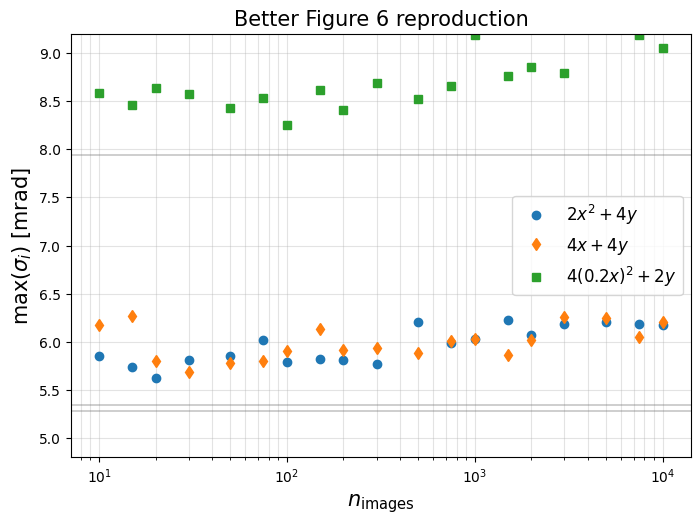

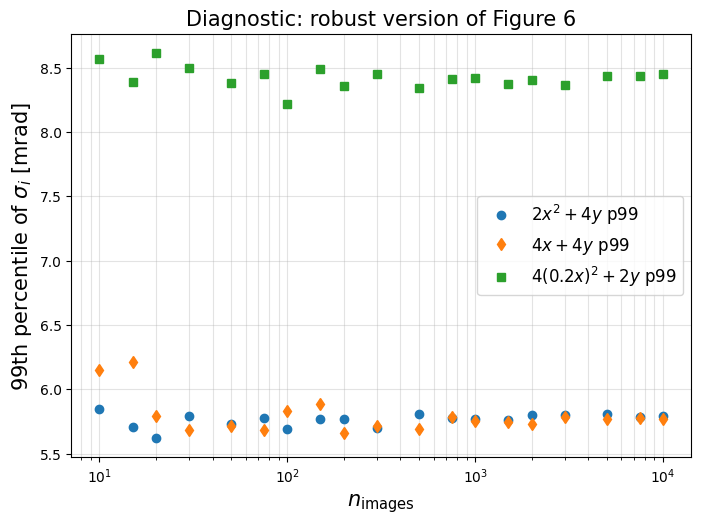

In [ ]:
|!pip -q install scikit-learn scikit-image

import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd
from skimage.measure import EllipseModel
from pathlib import Path
import time
def fast_pca_randomized(images, n_components=2, random_state=0):
    """
    Faster PCA for large n_images.

    images shape:
        (n_images, height, width)

    Uses randomized SVD instead of Gram matrix.
    This is important for n_images up to 10000.
    """

    n_images, height, width = images.shape

    X = images.reshape(n_images, height * width).astype(np.float32)

    mean_flat = X.mean(axis=0, keepdims=True)
    X_centered = X - mean_flat

    U, S, Vt = randomized_svd(
        X_centered,
        n_components=n_components,
        n_iter=5,
        random_state=random_state
    )

    scores = U * S[None, :]
    components = Vt.reshape(n_components, height, width)

    # deterministic sign convention
    for j in range(n_components):
        flat_comp = components[j].ravel()
        max_index = np.argmax(np.abs(flat_comp))

        if flat_comp[max_index] < 0:
            components[j] *= -1
            scores[:, j] *= -1

    mean_image = mean_flat.reshape(height, width)

    return mean_image, components, scores, S


def fit_ellipse_to_coefficients(scores):
    """
    Paper convention:
    fit ellipse to points (w1, -w2).
    """

    points = np.column_stack([scores[:, 0], -scores[:, 1]])

    ellipse = EllipseModel()
    success = ellipse.estimate(points)

    if not success:
        raise RuntimeError("Ellipse fit failed.")

    xc, yc, a, b, angle = ellipse.params

    return xc, yc, a, b, angle, points


def pspr_reconstruct_exact_fast(images, random_state=0):
    """
    PSPR:
        PCA -> ellipse fit -> ellipse correction -> phase reconstruction

    Faster version for Figure 6.
    """

    n_images, height, width = images.shape

    mean_image, components, scores, singular_values = fast_pca_randomized(
        images,
        n_components=2,
        random_state=random_state
    )

    xc, yc, a, b, angle, points = fit_ellipse_to_coefficients(scores)

    center = np.array([xc, yc])

    R_minus = np.array([
        [np.cos(-angle), -np.sin(-angle)],
        [np.sin(-angle),  np.cos(-angle)],
    ])

    R_plus = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)],
    ])

    # Paper Eq. 7 style coefficient correction
    W_corrected = (points - center) @ R_minus.T @ np.diag([1.0 / a, 1.0 / b])

    # Paper Eq. 8 style component correction
    P = components.reshape(2, height * width)
    P_corrected = np.diag([a, b]) @ R_plus @ P
    P_corrected = P_corrected.reshape(2, height, width)

    theta_rec = np.arctan2(W_corrected[:, 1], W_corrected[:, 0])
    gamma_rec = np.arctan2(P_corrected[1], P_corrected[0])

    return theta_rec, gamma_rec
def estimate_theta_error_for_fig6(
    pattern_id,
    n_atoms,
    n_images,
    n_runs,
    width=80,
    height=40,
    contrast=1.0,
    seed=0,
):
    """
    Estimate max(sigma_i) for Figure 6.

    sigma_i = std(theta_diff(i)) over many noisy runs.
    max(sigma_i) = worst-case reconstruction error.
    """

    rng = np.random.default_rng(seed)

    noiseless, gamma_true, theta_true, X, Y = generate_noiseless_synthetic_images(
        n_images=n_images,
        width=width,
        height=height,
        contrast=contrast,
        pattern_id=pattern_id,
    )

    theta_diffs = np.empty((n_runs, n_images), dtype=np.float32)

    failed = 0

    for r in range(n_runs):
        noisy = add_atom_shot_noise(
            noiseless,
            n_atoms=n_atoms,
            rng=rng
        )

        try:
            theta_rec, gamma_rec = pspr_reconstruct_exact_fast(
                noisy,
                random_state=seed + r
            )

            theta_diff, gamma_diff = align_reconstructed_phases(
                theta_true,
                theta_rec,
                gamma_true,
                gamma_rec
            )

            theta_diffs[r] = theta_diff.astype(np.float32)

        except Exception as exc:
            failed += 1
            theta_diffs[r] = np.nan

    sigma_i = np.nanstd(theta_diffs, axis=0, ddof=1)

    max_sigma_i = np.nanmax(sigma_i)

    # also useful diagnostic, not paper definition
    p99_sigma_i = np.nanpercentile(sigma_i, 99)

    return {
        "max_sigma_i": max_sigma_i,
        "p99_sigma_i": p99_sigma_i,
        "sigma_i": sigma_i,
        "failed": failed,
    }

N_RUNS_FIG6 = 200
# ==========================================================
# Figure 6 settings
# ==========================================================

N_RUNS_FIG6 = 200       # use 300 if Colab is okay
N_ATOMS_FIG6 = 100_000
CONTRAST = 1.0

# Use decent resolution but not too huge.
# Full 100x50 is slower. Start with 80x40.
WIDTH = 80
HEIGHT = 40

N_IMAGES_LIST = np.array([
    10,
    15,
    20,
    30,
    50,
    75,
    100,
    150,
    200,
    300,
    500,
    750,
    1000,
    1500,
    2000,
    3000,
    5000,
    7500,
    10000,
])

fig6_results = {
    1: [],
    2: [],
    3: [],
}

fig6_p99_results = {
    1: [],
    2: [],
    3: [],
}

fig6_failed = {
    1: [],
    2: [],
    3: [],
}

output_dir = Path("pspr_fig6__progress")
output_dir.mkdir(exist_ok=True)

start_total = time.time()

for pattern_id in [1, 2, 3]:
    print("\n" + "=" * 70)
    print(f"Pattern {pattern_id}")
    print("=" * 70)

    for n_images in N_IMAGES_LIST:
        start = time.time()

        result = estimate_theta_error_for_fig6_(
            pattern_id=pattern_id,
            n_atoms=N_ATOMS_FIG6,
            n_images=int(n_images),
            n_runs=N_RUNS_FIG6,
            width=WIDTH,
            height=HEIGHT,
            contrast=CONTRAST,
            seed=6000 + pattern_id * 100000 + int(n_images),
        )

        fig6_results[pattern_id].append(result["max_sigma_i"])
        fig6_p99_results[pattern_id].append(result["p99_sigma_i"])
        fig6_failed[pattern_id].append(result["failed"])

        elapsed = time.time() - start

        print(
            f"pattern={pattern_id}, "
            f"n_images={n_images:>5}, "
            f"max_sigma={1000*result['max_sigma_i']:.3f} mrad, "
            f"p99_sigma={1000*result['p99_sigma_i']:.3f} mrad, "
            f"failed={result['failed']}, "
            f"time={elapsed:.1f}s"
        )

        # Save progress after every point
        np.savez_compressed(
            output_dir / "fig6_progress.npz",
            N_IMAGES_LIST=N_IMAGES_LIST,
            pattern1=np.array(fig6_results[1]),
            pattern2=np.array(fig6_results[2]),
            pattern3=np.array(fig6_results[3]),
            pattern1_p99=np.array(fig6_p99_results[1]),
            pattern2_p99=np.array(fig6_p99_results[2]),
            pattern3_p99=np.array(fig6_p99_results[3]),
            pattern1_failed=np.array(fig6_failed[1]),
            pattern2_failed=np.array(fig6_failed[2]),
            pattern3_failed=np.array(fig6_failed[3]),
            N_RUNS_FIG6=N_RUNS_FIG6,
            N_ATOMS_FIG6=N_ATOMS_FIG6,
            WIDTH=WIDTH,
            HEIGHT=HEIGHT,
        )

print("\nTotal elapsed:", (time.time() - start_total) / 60, "minutes")

for pattern_id in [1, 2, 3]:
    fig6_results[pattern_id] = np.array(fig6_results[pattern_id])
    fig6_p99_results[pattern_id] = np.array(fig6_p99_results[pattern_id])

pattern_labels = {
    1: r"$2x^2 + 4y$",
    2: r"$4x + 4y$",
    3: r"$4(0.2x)^2 + 2y$",
}

markers = {
    1: "o",
    2: "d",
    3: "s",
}

# Paper fit constants
paper_a = {
    1: 1.69,
    2: 1.67,
    3: 2.51,
}

plt.figure(figsize=(8, 5.5))

for pattern_id in [1, 2, 3]:
    plt.semilogx(
        N_IMAGES_LIST[:len(fig6_results[pattern_id])],
        1000 * fig6_results[pattern_id],
        marker=markers[pattern_id],
        linestyle="none",
        markersize=6,
        label=pattern_labels[pattern_id],
    )

# Paper expected plateaus in mrad
for pattern_id in [1, 2, 3]:
    plateau_mrad = 1000 * paper_a[pattern_id] / np.sqrt(N_ATOMS_FIG6)

    plt.axhline(
        plateau_mrad,
        color="gray",
        linestyle="-",
        linewidth=1.2,
        alpha=0.45
    )

plt.xlabel(r"$n_{\mathrm{images}}$", fontsize=15)
plt.ylabel(r"$\max(\sigma_i)$ [mrad]", fontsize=15)
plt.title("Figure 6 reproduction", fontsize=15)

plt.xscale("log")
plt.ylim(4.8, 9.2)

plt.grid(True, which="both", alpha=0.35)
plt.legend(fontsize=12)

plt.show()
plt.figure(figsize=(8, 5.5))

for pattern_id in [1, 2, 3]:
    plt.semilogx(
        N_IMAGES_LIST[:len(fig6_p99_results[pattern_id])],
        1000 * fig6_p99_results[pattern_id],
        marker=markers[pattern_id],
        linestyle="none",
        markersize=6,
        label=pattern_labels[pattern_id] + " p99",
    )

plt.xlabel(r"$n_{\mathrm{images}}$", fontsize=15)
plt.ylabel(r"99th percentile of $\sigma_i$ [mrad]", fontsize=15)
plt.title("Diagnostic: robust version of Figure 6", fontsize=15)

plt.xscale("log")
plt.grid(True, which="both", alpha=0.35)
plt.legend(fontsize=12)

plt.show()



n_images = 10
  pattern=1, failed=0, median sigma_xy=1.8415e-01
  pattern=2, failed=0, median sigma_xy=1.8278e-01
  pattern=3, failed=0, median sigma_xy=1.8103e-01

n_images = 100
  pattern=1, failed=0, median sigma_xy=5.7758e-02
  pattern=2, failed=0, median sigma_xy=5.7183e-02
  pattern=3, failed=0, median sigma_xy=5.7436e-02

n_images = 1000
  pattern=1, failed=0, median sigma_xy=1.8369e-02
  pattern=2, failed=0, median sigma_xy=1.8165e-02
  pattern=3, failed=0, median sigma_xy=1.8135e-02

Elapsed time: 74.55853986740112 seconds


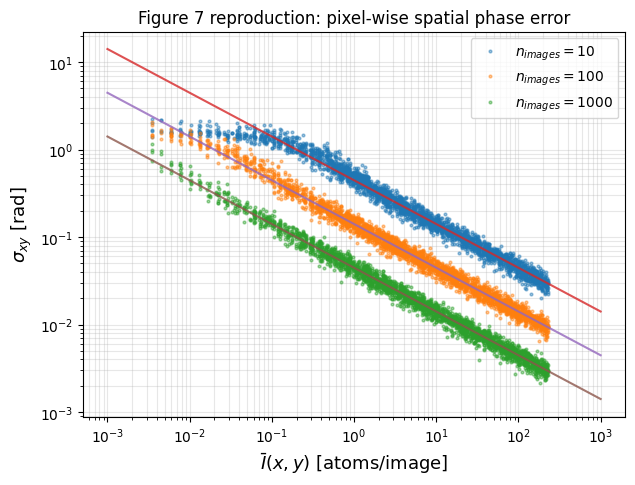

In [22]:
N_RUNS_FIG7 = 30
N_ATOMS_FIG7 = 100_000

# Paper uses 10, 100, 1000, 10000 images.
# 10000 can be heavy in Colab, so start with this:
N_IMAGES_FIG7_LIST = np.array([10, 100, 1000])

fig7_points = {}

start = time.time()

for n_images in N_IMAGES_FIG7_LIST:
    print(f"\nn_images = {n_images}")

    all_Ibar = []
    all_sigma_xy = []

    for pattern_id in [1, 2, 3]:
        sigma_xy, Ibar, failed = estimate_gamma_xy_for_setting(
            pattern_id=pattern_id,
            n_atoms=N_ATOMS_FIG7,
            n_images=int(n_images),
            n_runs=N_RUNS_FIG7,
            width=WIDTH,
            height=HEIGHT,
            contrast=CONTRAST,
            seed=3000 + pattern_id * 100 + int(n_images),
        )

        all_Ibar.append(Ibar.ravel())
        all_sigma_xy.append(sigma_xy.ravel())

        print(
            f"  pattern={pattern_id}, "
            f"failed={failed}, "
            f"median sigma_xy={np.nanmedian(sigma_xy):.4e}"
        )

    all_Ibar = np.concatenate(all_Ibar)
    all_sigma_xy = np.concatenate(all_sigma_xy)

    # Remove invalid / empty pixels
    valid = (
        np.isfinite(all_Ibar)
        & np.isfinite(all_sigma_xy)
        & (all_Ibar > 1e-3)
        & (all_sigma_xy > 0)
    )

    fig7_points[int(n_images)] = {
        "Ibar": all_Ibar[valid],
        "sigma_xy": all_sigma_xy[valid],
    }

print("\nElapsed time:", time.time() - start, "seconds")
plt.figure(figsize=(7, 5))

for n_images in N_IMAGES_FIG7_LIST:
    Ibar = fig7_points[int(n_images)]["Ibar"]
    sigma_xy = fig7_points[int(n_images)]["sigma_xy"]

    # Downsample points for cleaner plot
    rng = np.random.default_rng(42 + int(n_images))
    max_points = 3000

    if len(Ibar) > max_points:
        idx = rng.choice(len(Ibar), size=max_points, replace=False)
        Ibar_plot = Ibar[idx]
        sigma_plot = sigma_xy[idx]
    else:
        Ibar_plot = Ibar
        sigma_plot = sigma_xy

    plt.loglog(
        Ibar_plot,
        sigma_plot,
        linestyle="none",
        marker="o",
        markersize=2,
        alpha=0.45,
        label=rf"$n_{{images}}={n_images}$",
    )

# Paper scaling:
# sigma_xy = b / sqrt(n_images * Ibar)
b_paper = 1.41
Ibar_line = np.logspace(-3, 3, 300)

for n_images in N_IMAGES_FIG7_LIST:
    plt.loglog(
        Ibar_line,
        b_paper / np.sqrt(n_images * Ibar_line),
        linestyle="-",
        linewidth=1.5,
        alpha=0.8,
    )

plt.xlabel(r"$\bar{I}(x,y)$ [atoms/image]", fontsize=13)
plt.ylabel(r"$\sigma_{xy}$ [rad]", fontsize=13)
plt.title("Figure 7 reproduction: pixel-wise spatial phase error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()